In [1]:
import sys
sys.path.append('..')

from Agent.config import LLM, SMALL_LLM, SMART_LLM, EMBEDDING, CLIENT
from IPython.display import display, Image, Markdown

In [2]:
from langchain_chroma import Chroma


database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= '../db/by-article-upstage',
  embedding_function= EMBEDDING     
)

retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 20,
        'fetch_k': 50,
        'lambda_mult': 0.6
    }
)


In [3]:
from langchain_core.tools.retriever import create_retriever_tool
from langchain_core.prompts import PromptTemplate

retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='search_tax_law',  # 동사로 시작하는 이름 권장
    description='''소득세 관련 법령 조문을 검색합니다.

이럴 때 사용:
- 과세표준 계산 근거가 필요할 때
- 세율표, 공제 조건 등 법적 기준 확인
- 특정 조문 번호로 검색 (예: "종부세법 9조")

이럴 때 사용하지 마세요:
- 단순 세금 계산 → calculate_tax 도구
- 최신 공시가격/공정시장가액비율 → web_search 도구

반환: 관련 법령 조문 (최대 4개, 출처 포함)
''',
    document_prompt=PromptTemplate.from_template(
        "[{source} {article}]\n{page_content}"
    ),
    document_separator="\n\n"
)

In [4]:
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.utilities.semanticscholar import SemanticScholarAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults


@tool       # 데코레이터 @tool로 감싸고
def add(num1: int, num2: int) -> int:     # 함수와 변수의 이름, typehint가 schema(구조)로서, JSON 형식으로 LLM에 전달됨
    '''
    정수 num1와 num2를 더합니다. 
    '''         # 이 부분의 description(프롬프트와 같음)도 마찬가지로 LLM에 전달됨
    return num1+num2

@tool
def multiply(num1: int, num2: int) -> int:
    '''
    정수 num1와 num2를 곱합니다. 
    '''
    return num1*num2

search_tool = TavilySearchResults()

@tool
def search(query: str) -> str:
    '''
    사용자의 질문에 알고 있는 지식만으로 답변하기 힘든 경우,
    주어진 query에 대해 DuckDuckGo 검색을 수행하고, 요약된 결과를 반환합니다.
    '''
    # 1. 검색 수행
    results = search_tool.invoke(query)
    
    # 2. 요약 프롬프트
    prompt = ChatPromptTemplate.from_messages([
        ("system", "당신은 검색 결과를 요약하는 전문가입니다. 검색 결과를 바탕으로 사용자의 질문에 간결하고 정확하게 답변하세요."),
        ("human", "질문: {query}\n\n검색 결과:\n{results}\n\n위 검색 결과를 바탕으로 질문에 답변해주세요.")
    ])
    
    # 3. Chain 구성 (비용 절약을 위해 small_llm 사용)
    chain = prompt | SMALL_LLM | StrOutputParser()
    
    # 4. 요약 실행
    summary = chain.invoke({"query": query, "results": results})
    
    return summary


semantic_scholar_wrapper = SemanticScholarAPIWrapper(
    top_k_results=5,
    doc_content_chars_max=6000,  # 더 긴 초록
)

@tool
def search_semantic_scholar(query: str) -> str:
    '''
    Semantic Scholar에서 peer-reviewed 학술 논문을 검색합니다.
    인용 수(citation count)가 포함되어 논문 품질을 판단할 수 있습니다.
    
    Args:
        query: 검색어 (예: "LLM agent reasoning")
    '''
    return semantic_scholar_wrapper.run(query)

In [5]:
@tool
def search_income_tax_law(query: str) -> str:
    '''소득세 관련 법령 조문을 검색합니다.

    이럴 때 사용:
    - 과세표준 계산 근거가 필요할 때
    - 세율표, 공제 조건 등 법적 기준 확인
    - 특정 조문 번호로 검색 (예: "소득세법 55조")

    이럴 때 사용하지 마세요:
    - 단순 세금 계산 → calculate_tax 도구
    - 최신 세율/공제 한도 → web_search 도구

    반환: 관련 법령 조문 (최대 4개, 출처 포함)
    '''
    try:
        docs = retriever.invoke(query)
    except Exception as e:
        return f"검색 중 오류 발생: {str(e)}"
    
    if not docs:
        return "관련 법령을 찾지 못했습니다. 다른 키워드로 검색해주세요."
    
    # 중복 조문 제거
    seen = set()
    unique_docs = []
    for doc in docs:
        key = doc.metadata.get('article', doc.page_content[:50])
        if key not in seen:
            seen.add(key)
            unique_docs.append(doc)
    
    # 포맷팅
    results = []
    for doc in unique_docs[:4]:
        source = doc.metadata.get('source', '출처 미상')
        article = doc.metadata.get('article', '')
        results.append(f"[{source} {article}]\n{doc.page_content}")
    
    return "\n\n".join(results)

In [6]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search, search_semantic_scholar, search_income_tax_law]

small_llm_with_tools = SMALL_LLM.bind_tools(tool_list)
smart_llm_with_tools = SMALL_LLM.bind_tools(tool_list)

tool_node = ToolNode(tool_list)

In [7]:
from langgraph.graph import START, END
from langgraph.graph import MessagesState, StateGraph
from langchain_core.messages import RemoveMessage, SystemMessage



class AgentState(MessagesState):
    summary: str = None

message_count_to_keep = 8

def summarize_message(state: AgentState):
    message = state['messages'][:-message_count_to_keep]
    summary = state['summary']

    chat_text = "\n".join(
        f"{m.type}: {m.content}"
        for m in message
        if m.content
    )

    summary_prompt = f"""\
You are a conversation summarizer. Summarize the chat history below into a concise summary.

Rules:
- Preserve all specific names, numbers, dates, and key decisions
- Capture what the user requested and what actions were taken
- Note any tool calls and their results (e.g. emails sent, searches performed)
- Keep the summary under 200 words
- Write in the same language the user used

Chat history:
{chat_text}

Summary:"""
    if summary:
        summary_prompt = f"""\
You are a conversation summarizer. Update the existing summary by incorporating the new chat history below.

Rules:
- Merge new information into the existing summary, do not simply append
- Preserve all specific names, numbers, dates, and key decisions from both the existing summary and new history
- Remove outdated or superseded information (e.g. if a decision was changed)
- Capture what the user requested and what actions were taken
- Note any tool calls and their results
- Keep the updated summary under 300 words
- Write in the same language the user used

Existing summary:
{summary}

New chat history:
{chat_text
}

Updated summary:"""

    response = SMALL_LLM.invoke(summary_prompt)
    return {'summary': response.content}

def delete_messages(state: AgentState):
    messages = state['messages']
    deleted_messages = [RemoveMessage(id=message.id) for message in messages[:-message_count_to_keep]]
    return {'messages': deleted_messages}

def agent(state: AgentState):
    summary = state['summary']
    messages = state['messages']
    if summary:
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
    
    response = small_llm_with_tools.invoke(messages)
    return {'messages': [response]}

def should_continue(state: AgentState):
    messages = state['messages']
    if messages[-1].tool_calls:
        return 'tools'
    if len(messages) > message_count_to_keep:
        return 'summarize_message'
    return END





graph_builder = StateGraph(AgentState)


graph_builder.add_node('agent', agent) 
graph_builder.add_node('tools', tool_node)
graph_builder.add_node('summarize_message', summarize_message)
graph_builder.add_node('delete_messages', delete_messages)

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent', 
    should_continue,
    {
        'tools': 'tools',
        'summarize_message': 'summarize_message',
        END: END
    }
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_message', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

<!-- ## 여기서 checkpoint 선언 -->

In [8]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

In [9]:
graph = graph_builder.compile(
    checkpointer=checkpointer
)

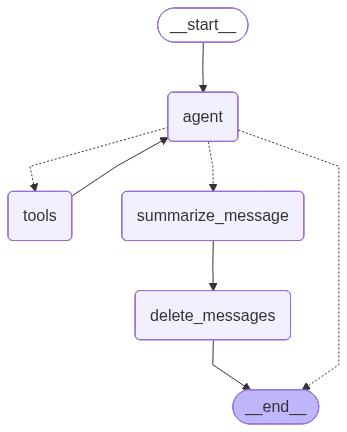

In [10]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
test_config = {
    'configurable': {
        'thread_id': 'test-thread-001'
    }
}

In [12]:
from langchain_core.messages import HumanMessage

query = '사업소득만 있는 사람은 교육비세액공제를 받을 수 없나요?'

for chunk in graph.stream(
    {'messages': [HumanMessage(query)], 'summary': ''}, config=test_config, stream_mode= 'values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

사업소득만 있는 사람은 교육비세액공제를 받을 수 없나요?
================================== Ai Message ==================================

[{'text': '이 질문은 세법의 구체적인 기준을 확인해야 하므로, 소득세법 관련 조항을 검색해드리겠습니다.', 'type': 'text'}, {'id': 'toolu_01Ljk6SZGrBah2nGN1i2hkmP', 'input': {'query': '교육비세액공제 사업소득'}, 'name': 'search_income_tax_law', 'type': 'tool_use'}, {'id': 'toolu_014og56djQyNE63qiFmCo2Ku', 'input': {'query': '교육비세액공제 요건'}, 'name': 'search_income_tax_law', 'type': 'tool_use'}]
Tool Calls:
  search_income_tax_law (toolu_01Ljk6SZGrBah2nGN1i2hkmP)
 Call ID: toolu_01Ljk6SZGrBah2nGN1i2hkmP
  Args:
    query: 교육비세액공제 사업소득
  search_income_tax_law (toolu_014og56djQyNE63qiFmCo2Ku)
 Call ID: toolu_014og56djQyNE63qiFmCo2Ku
  Args:
    query: 교육비세액공제 요건
================================= Tool Message =================================
Name: search_income_tax_law

[소득세법 제59조의4]
제59조의4(특별세액공제) ③ 근로소득이 있는 거주자가 그 거주자와 기본공제대상자(나이의 제한을 받지 아니하되, 제3호나목

## config로 이전 state를 불러와 대화내역 확인하기

In [25]:
current_message_list = graph.get_state(test_config).values['summary']
current_message_list

'**요약:**\n\n사용자가 사업소득만 있는 사람이 월세세액공제를 받을 수 있는지 문의했습니다.\n\n**수행된 작업:**\n1. 첫 번째 검색: "월세세액공제 요건 사업소득"으로 소득세법 검색 수행\n   - 결과: 소득세법 제144조의3(연말정산), 제59조의4(특별세액공제/표준세액공제), 제64조의2(주택임대소득), 제59조(근로소득세액공제) 조항 확인\n   - 월세세액공제에 대한 직접적인 정보는 나오지 않음\n\n2. 두 번째 검색: "월세세액공제 근로소득 요건"으로 재검색 진행 중\n\n**현재 상태:**\n월세세액공제의 구체적인 요건(특히 사업소득자의 적용 가능 여부)을 확인하기 위해 추가 검색을 수행하고 있습니다. 아직 최종 답변은 제공되지 않았습니다.'

In [26]:
current_message_list = graph.get_state(test_config).values['messages']
current_message_list

[ToolMessage(content='[소득세법 제59조]\n제59조(근로소득세액공제) ①근로소득이 있는 거주자에 대해서는 그 근로소득에 대한 종합소득산출세액에서 다음의 금액을 공제한다.\n┌─────────────────┬───────────────────────┐\n│근로소득에 대한 종합소득 산출세액 │공제액 │\n├─────────────────┼───────────────────────┤\n│130만원 이하 │산출세액의 100분의 55 │\n├─────────────────┼───────────────────────┤\n│130만원 초과 │71만5천원＋(130만원을 초과하는 금액의 100분의 │\n│ │30) │\n└─────────────────┴───────────────────────┘\n\n[소득세법 제52조]\n제52조(특별소득공제) ⑤ 근로소득이 있는 거주자로서 주택을 소유하지 아니하거나 1주택을 보유한 세대의 세대주(세대주가 이 항, 제4항 및 「조세특례제한법」 제87조제2항에 따른 공제를 받지 아니하는 경우에는 세대의 구성원 중 근로소득이 있는 자를 말하며, 대통령령으로 정하는 외국인을 포함한다)가 취득 당시 제99조제1항에 따른 주택의 기준시가가 6억원 이하인 주택을 취득하기 위하여 그 주택에 저당권을 설정하고 금융회사등 또는 「주택도시기금법」에 따른 주택도시기금으로부터 차입한 대통령령으로 정하는 장기주택저당차입금(주택을 취득함으로써 승계받은 장기주택저당차입금을 포함하며, 이하 이 항 및 제6항에서 "장기주택저당차입금"이라 한다)의 이자를 지급하였을 때에는 해당 과세기간에 지급한 이자 상환액을 다음 각 호의 기준에 따라 그 과세기간의 근로소득금액에서 공제한다. 다만, 그 공제하는 금액과 제4항 및 「조세특례제한법」 제87조제2항에 따른 주택청약종합저축 등에 대한 소득공제 금액의 합계액이 연 800만원(차입금의 상환기간이 15년 이상인 장기주택저당차입금에 대하여 적용하며, 이하 이 항 및 제6항에서 "공제한도"라 한다)을 초과하는 경우 

## 수동으로 chatting history 지우기

In [27]:
# from langchain_core.messages import RemoveMessage

# for index, message in enumerate(current_message_list):
#     if index < len(current_message_list) - 1:
#         graph.update_state(
#             test_config,
#             {'messages': [RemoveMessage(id=message.id)]}
#         )

In [28]:
### 대화 히스토리 관리 방법 ###

# 1. 선입선출 삭제 (context를 잃어버리는 문제 발생)

# 2. 삭제 이전에 요약 후 삭제 


# 이를 반영하는 방법 
# 1. 수동으로 RemoveMessage
# 2. RemoveAndSummarizeMessage Tool 만들어 node에 반영